In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

DATA_DIR = "/Users/andesoncortes/Downloads/severstal-steel-defect-detection"

TRAIN_IMAGES = os.path.join(DATA_DIR, "train_images")

df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))

df.head()

,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0007a71bf.jpg,3,18661 28 18863 82 19091 110 19347 110 19603 11...
2,000a4bcdd.jpg,1,37607 3 37858 8 38108 14 38359 20 38610 25 388...
3,000f6bf48.jpg,4,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,3,229501 11 229741 33 229981 55 230221 77 230468...


In [ ]:
Load train.csv and examine its structure. How many rows does it have? What are the columns? Why doesn't the row count match the number of images in the folder?

Hint: Use df.shape, df.columns, and df.head(10) to look at what you've got. Notice that the same ImageId can appear more than once — why would that be?

In [7]:
df.shape

(7095, 3)

In [8]:
df.columns

Index(['ImageId', 'ClassId', 'EncodedPixels'], dtype='str')

In [16]:
df.head(10)

,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0007a71bf.jpg,3,18661 28 18863 82 19091 110 19347 110 19603 11...
2,000a4bcdd.jpg,1,37607 3 37858 8 38108 14 38359 20 38610 25 388...
3,000f6bf48.jpg,4,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,3,229501 11 229741 33 229981 55 230221 77 230468...
5,0025bde0c.jpg,3,8458 14 8707 35 8963 48 9219 71 9475 88 9731 8...
6,0025bde0c.jpg,4,315139 8 315395 15 315651 16 315906 17 316162 ...
7,002af848d.jpg,4,290800 6 291055 13 291311 15 291566 18 291822 ...
8,002fc4e19.jpg,1,146021 3 146275 10 146529 40 146783 46 147038 ...
9,002fc4e19.jpg,2,145658 7 145901 20 146144 33 146386 47 146629 ...


In [ ]:
The CSV does not have one row per image. It has one row per image+ defect class. Each steel image can have up to four defect types, so every
image can appear four times (Class 1-4). The EncodedPixels column contains the segmentation mask only when that defect exists.

In [ ]:
How many unique images are in the CSV? How many images are in the train_images/ folder?

In [11]:
unique_in_csv = df["ImageId"].nunique()
total_in_folder = len(os.listdir(TRAIN_IMAGES))
print(f"Unique in CSV: {unique_in_csv}, Total in folder: {total_in_folder}")

Unique in CSV: 6666, Total in folder: 12568


In [ ]:
What are the unique defect class IDs? Are there rows where EncodedPixels is empty?

In [13]:
print(df["ClassId"].unique())
print(f"Null EncodedPixels: {df['EncodedPixels'].isnull().sum()}")

[1 3 4 2]
Null EncodedPixels: 0


In [ ]:
The unique defect is class IDs : [1 3 4 2]
No empty rows

In [ ]:
Part 2 — Class Distribution

In [ ]:
Count defective images per class and make a bar chart.

ClassId
1     897
2     247
3    5150
4     801
Name: count, dtype: int64


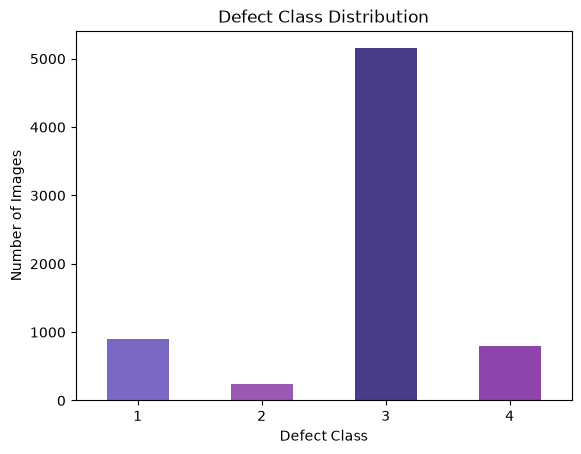

In [18]:
defective = df[df["EncodedPixels"].notna()]
class_counts = defective["ClassId"].value_counts().sort_index()
print(class_counts)

# Bar chart
class_counts.plot(kind="bar", color=["#7B68C4", "#9B59B6", "#4A3A8A", "#8E44AD"])
plt.xlabel("Defect Class")
plt.ylabel("Number of Images")
plt.title("Defect Class Distribution")
plt.xticks(rotation=0)
plt.show()

In [ ]:
How many images have no defect at all?

In [21]:
all_images = set(os.listdir(TRAIN_IMAGES))
defective_images = set(defective["ImageId"].unique())
no_defect_images = all_images - defective_images
print(f"No defect: {len(no_defect_images)}, Defective: {len(defective_images)}")

No defect: 5902, Defective: 6666


In [ ]:
Write out the full 5-class sample count table. 

ClassId
1             897
2             247
3            5150
4             801
No Defect    5902
Name: count, dtype: int64


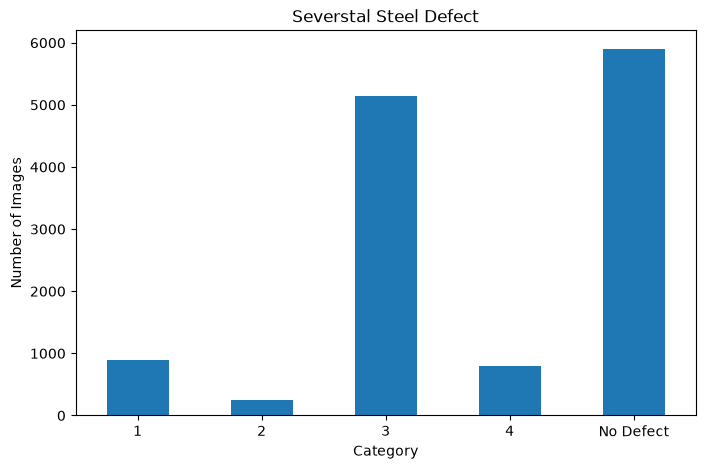

In [25]:
summary = class_counts.copy()
summary = summary.sort_index()
summary["No Defect"] = len(no_defect_images)

print(summary)

summary.plot(
    kind="bar",
    figsize=(8,5)
)

plt.xlabel("Category")
plt.ylabel("Number of Images")
plt.title("Severstal Steel Defect")
plt.xticks(rotation=0)
plt.show()


In [ ]:
Part 3 — Multi-Label Investigation

In [ ]:
Can a single image have more than one defect type? Find out.

In [26]:
defects_per_image = defective.groupby("ImageId")["ClassId"].nunique()
print(defects_per_image.value_counts())


ClassId
1    6239
2     425
3       2
Name: count, dtype: int64


In [ ]:
For multi-defect images, which class combinations show up?

In [27]:
multi= defective.groupby("ImageId")["ClassId"].apply(
    lambda x: tuple(sorted(x.unique()))
)
multi_only = multi[multi.apply(len)>1]
print(multi_only.value_counts().head(5))


ClassId
(3, 4)       284
(1, 3)        91
(1, 2)        35
(2, 3)        14
(1, 2, 3)      2
Name: count, dtype: int64


In [ ]:
(Written answer, no code needed) If an image has both Class 1 and Class 3 defects, 
but your classifier can only pick ONE label — what would you do?
Think of at least two options. There's no single right answer here.

1.I probably assing the class that represents the most serious defect.
2. Create another category for images that have more than one defect.




    

In [ ]:
Part 4 — Visual Inspection

In [ ]:
Display sample images from each defect class.

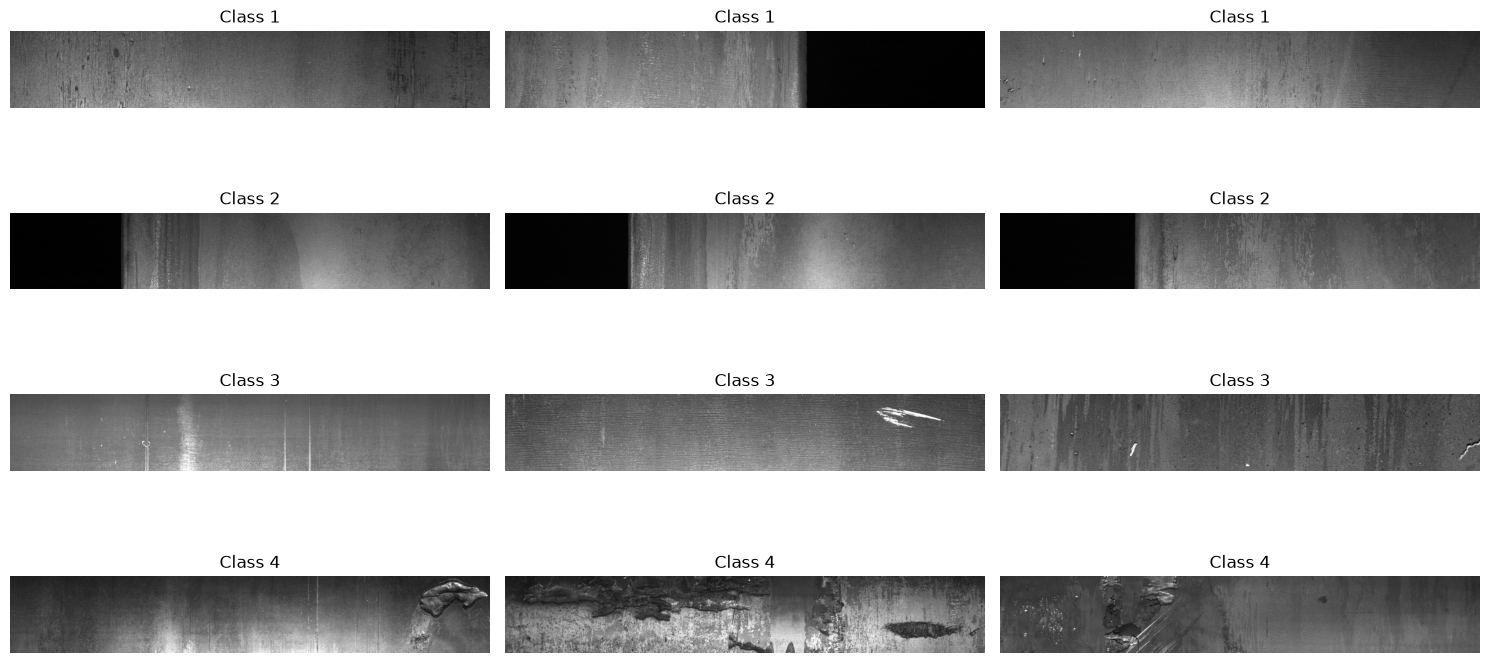

In [29]:
ig, axes = plt.subplots(4, 3, figsize=(15, 8))

for row, class_id in enumerate([1, 2, 3, 4]):
    class_images = defective[defective["ClassId"] == class_id]["ImageId"].unique()
    samples = np.random.choice(class_images, size=3, replace=False)
    for col, img_name in enumerate(samples):
        img = Image.open(os.path.join(TRAIN_IMAGES, img_name))
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(f"Class {class_id}")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
Look at the images and ask yourself: could I tell these apart?
yes, we could set them apart; the defects are very noticeable

In [ ]:
Display some "no defect" images. Do they really look clean?

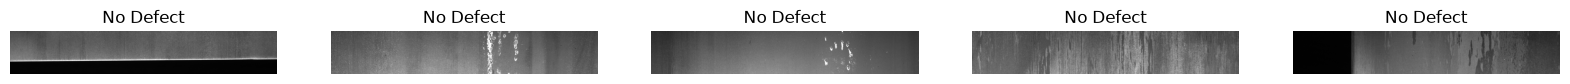

In [31]:
no_defect_samples = np.random.choice(list(no_defect_images), size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(20, 3))
for i, img_name in enumerate(no_defect_samples):
    img = Image.open(os.path.join(TRAIN_IMAGES, img_name))
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title("No Defect")
    axes[i].axis("off")
plt.show()

In [ ]:
No, you can see from the images that is has many defects.

In [32]:
sample_img = Image.open(os.path.join(TRAIN_IMAGES, os.listdir(TRAIN_IMAGES)[0]))
print(f"Size: {sample_img.size}")  # (width, height)

Size: (1600, 256)


In [ ]:
Part 5 — Thinking Ahead

In [ ]:
Based on everything you've found, list the top 3 data challenges you'd face before training a classifier. 
(No code — just write your thoughts in a markdown cell.)  

1. Class Imblalance : Some class defects may have more images than others
2. Multiple defects in a single image 
3. Not enoght datasets and limited number of examples for certain defects.
    

In [ ]:
We used EncodedPixels only to check "is there a defect?" — but it actually contains exact pixel locations of every defect. 
What information are we throwing away? When might that matter?

1.we throwing away information like defect size, defect location, number of defects. 
2. This matter special in quality control, the results can not be precises. 

